In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from clustergram import Clustergram

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Беремо готовий датасет Iris зі sklearn. Це проміри квіток: довжина/ширина
# чашолистка (sepal) і пелюстки (petal) у сантиметрах. Колонку species лишаємо
# лише для контексту - кластеризацію робимо без неї (unsupervised).
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species_code"]
df["species"] = df["species_code"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="species_code")

features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df.shape

(150, 5)

In [3]:
# Дивимось перші рядки
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Типи, пропуски, дублікати
print(df.dtypes)
print()
print("пропусків:", df.isna().sum().sum())
print("дублікатів:", df.duplicated().sum())

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

пропусків: 0
дублікатів: 1


In [5]:
# Базова статистика по чотирьох ознаках
df[features].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Скільки об'єктів кожного справжнього виду - для контексту.
# Бачимо, що датасет збалансований: по 50 квіток кожного з трьох видів.
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

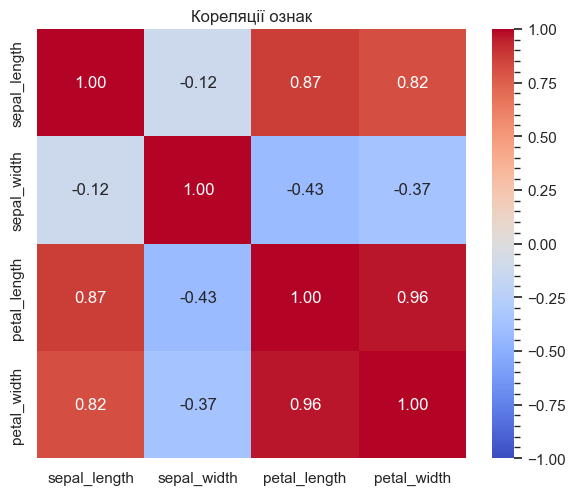

In [7]:
# Крок 2. Графічний аналіз
# Кореляції між ознаками. Видно сильний зв'язок petal_length з petal_width
# і з sepal_length - тобто пелюстки несуть багато спільної інформації.
corr = df[features].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Кореляції ознак")
plt.tight_layout()
plt.show()

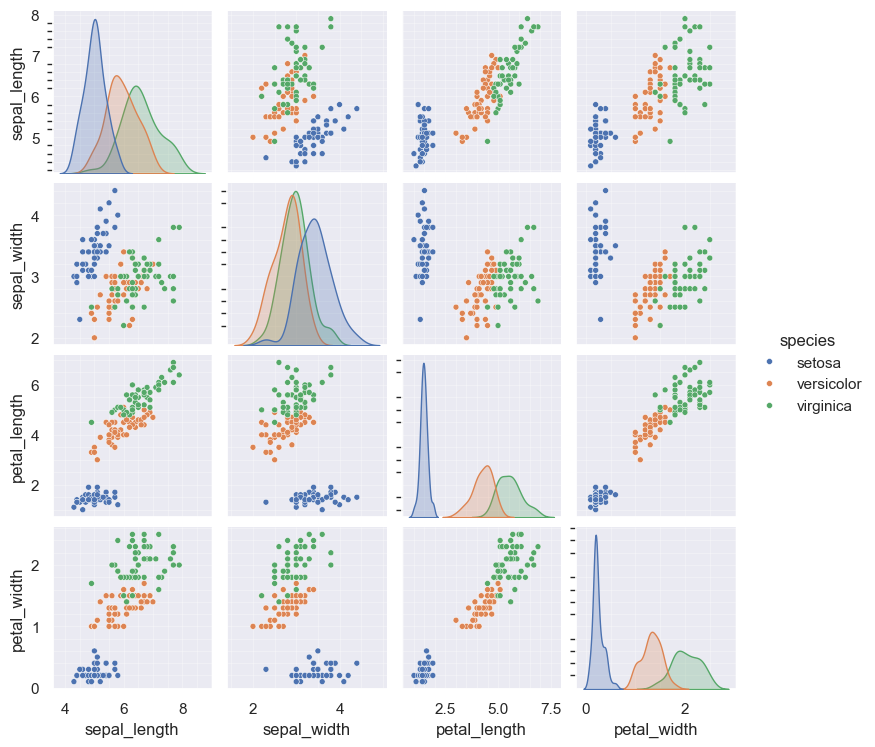

In [8]:
# Парні розподіли, розфарбовані за справжнім видом.
# Добре видно, що setosa стоїть окремою щільною групою, а versicolor і
# virginica частково перетинаються. Найкраще види розводять саме пелюстки.
sns.pairplot(df, vars=features, hue="species", height=1.9, plot_kws={"s": 18})
plt.show()

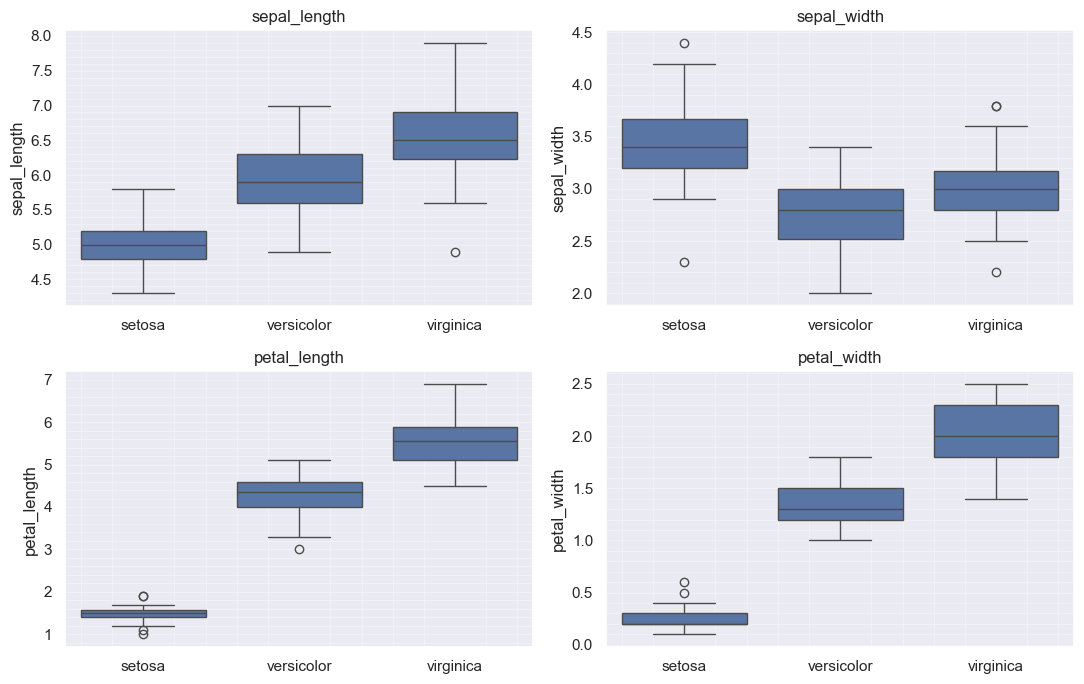

In [9]:
# Боксплоти кожної ознаки по видах.
# По пелюстках видно чіткі сходинки між видами, по чашолистках - сильне
# перекриття. Тобто структуру в даних найбільше формують petal-ознаки.
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [10]:
# Крок 3. Фіча-інжиніринг
# Кластеризацію робимо без таргета, тож нові фічі тут - лише щоб перевірити,
# чи не дасть якась похідна ознака сильніший сигнал за вихідні. Пробуємо площі
# (довжина * ширина) і відношення довжина/ширина для пелюстки й чашолистка.
df["petal_area"] = df["petal_length"] * df["petal_width"]
df["sepal_area"] = df["sepal_length"] * df["sepal_width"]
df["petal_ratio"] = df["petal_length"] / df["petal_width"]
df["sepal_ratio"] = df["sepal_length"] / df["sepal_width"]

candidates = ["petal_area", "sepal_area", "petal_ratio", "sepal_ratio"]
df[features + candidates].describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width,petal_area,sepal_area,petal_ratio,sepal_ratio
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,5.79,17.82,4.31,1.95
std,0.83,0.44,1.77,0.76,4.71,3.36,2.49,0.40
min,4.30,2.00,1.00,0.10,0.11,10.00,2.12,1.27
25%,5.10,2.80,1.60,0.30,0.42,15.66,2.80,1.55
50%,5.80,3.00,4.35,1.30,5.62,17.66,3.30,2.03
75%,6.40,3.30,5.10,1.80,9.69,20.32,4.67,2.22
max,7.90,4.40,6.90,2.50,15.87,30.02,15.00,2.96


In [11]:
# Міряємо сигнал mutual info відносно справжнього виду (тільки як орієнтир,
# наскільки ознака розводить природні групи). Рахуємо для вихідних і нових фіч.
y = df["species"]
mi = mutual_info_classif(df[features + candidates], y, random_state=0)
mi_scores = pd.Series(mi, index=features + candidates).sort_values(ascending=False)
mi_scores.round(3)

petal_area      1.043
petal_width     0.992
petal_length    0.988
petal_ratio     0.622
sepal_ratio     0.608
sepal_length    0.496
sepal_width     0.254
sepal_area      0.015
dtype: float64

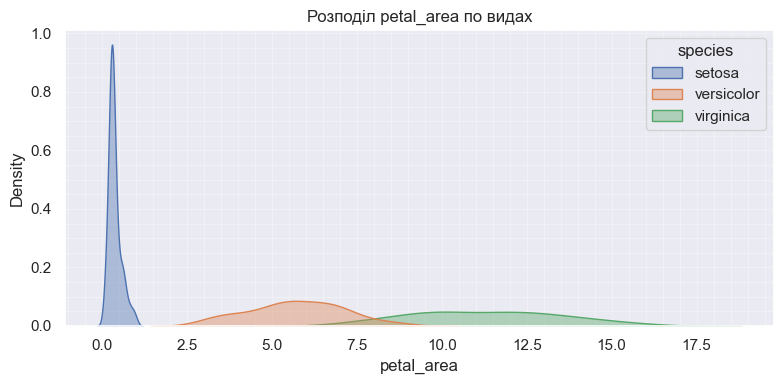

In [12]:
# Найсильніший сигнал очікувано у petal-ознак і в petal_area. Дивимось, як
# petal_area розводить види: setosa відділяється повністю, а versicolor і
# virginica трохи перетинаються.
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="petal_area", hue="species", fill=True, alpha=0.4)
plt.title("Розподіл petal_area по видах")
plt.tight_layout()
plt.show()

In [13]:
# petal_area має найсильніший сигнал, але вона майже повністю повторює
# petal_length і petal_width (це їх добуток), тобто нової інформації не додає,
# лише подвоїла б вагу пелюсток при рахунку відстаней. Відношення дають слабкий
# сигнал. Тому для кластеризації лишаємо вихідні 4 ознаки без похідних.
cluster_features = features
cluster_features

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [14]:
# Крок 4. Масштабування
# Усі три алгоритми рахують відстані між точками, тому ознаки треба привести до
# однієї шкали, щоб та, у якої більший розкид, не перетягувала на себе відстань.
# Ознаки Iris усі в сантиметрах і близькі за величиною, тож ефект тут помірний,
# але sepal_width має найменший розкид - стандартизація вирівнює всі чотири.
scaler = StandardScaler()
X = scaler.fit_transform(df[cluster_features])
X = pd.DataFrame(X, columns=cluster_features)
X.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71


In [15]:
# Крок 5. k-Means: розбиття на 2..10 кластерів
# Для кожної кількості кластерів рахуємо дві речі: inertia (сума квадратів
# відстаней до центрів - для методу ліктя) і silhouette (наскільки об'єкти
# добре лежать у своїх кластерах, чим ближче до 1, тим краще).
k_range = range(2, 11)
km_inertia, km_sil = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    km_inertia.append(km.inertia_)
    km_sil.append(silhouette_score(X, labels))

sil_kmeans = dict(zip(k_range, km_sil))
pd.DataFrame({"k": list(k_range), "inertia": np.round(km_inertia, 1),
             "silhouette": np.round(km_sil, 3)})

,k,inertia,silhouette
0,2,222.4,0.582
1,3,139.8,0.460
2,4,114.1,0.387
3,5,90.9,0.346
4,6,81.5,0.317
5,7,72.6,0.320
6,8,62.5,0.339
7,9,55.1,0.342
8,10,47.4,0.352


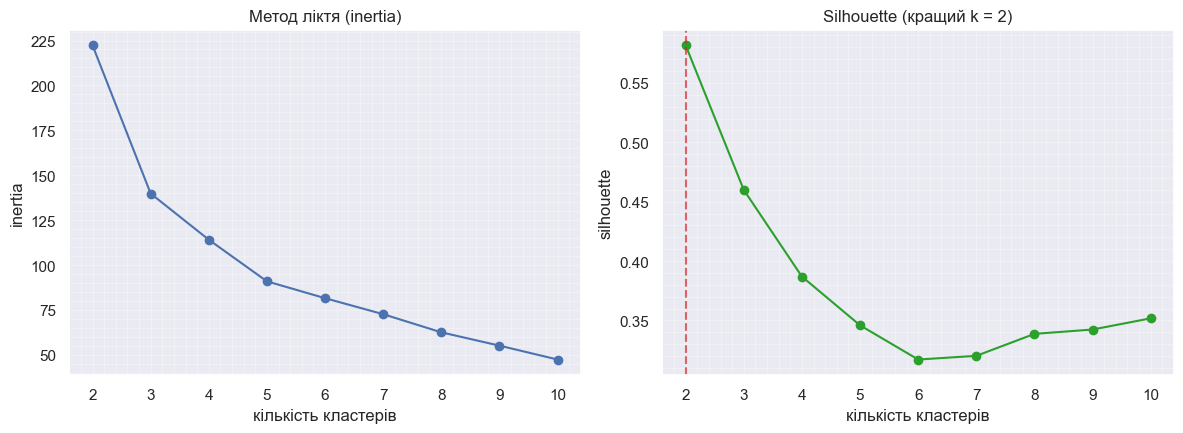

In [16]:
# Зліва метод ліктя, справа silhouette. На лікті злам десь на 2-3 кластерах,
# а silhouette найвищий саме там - позначимо кращий за silhouette.
best_k = max(sil_kmeans, key=sil_kmeans.get)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), km_inertia, marker="o")
axes[0].set_title("Метод ліктя (inertia)")
axes[0].set_xlabel("кількість кластерів")
axes[0].set_ylabel("inertia")

axes[1].plot(list(k_range), km_sil, marker="o", color="tab:green")
axes[1].axvline(best_k, color="tab:red", ls="--", alpha=0.7)
axes[1].set_title(f"Silhouette (кращий k = {best_k})")
axes[1].set_xlabel("кількість кластерів")
axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

In [17]:
# Крок 6. Ієрархічна (агломеративна) кластеризація: 2..10 кластерів
# Тут центрів наперед не задаємо - алгоритм зливає найближчі кластери знизу
# вгору (linkage за замовчуванням ward). Для кожного k рахуємо silhouette.
ag_sil = []
for k in k_range:
    ag = AgglomerativeClustering(n_clusters=k)
    labels = ag.fit_predict(X)
    ag_sil.append(silhouette_score(X, labels))

sil_agglo = dict(zip(k_range, ag_sil))
pd.DataFrame({"k": list(k_range), "silhouette": np.round(ag_sil, 3)})

,k,silhouette
0,2,0.577
1,3,0.447
2,4,0.401
3,5,0.331
4,6,0.315
5,7,0.317
6,8,0.311
7,9,0.311
8,10,0.316


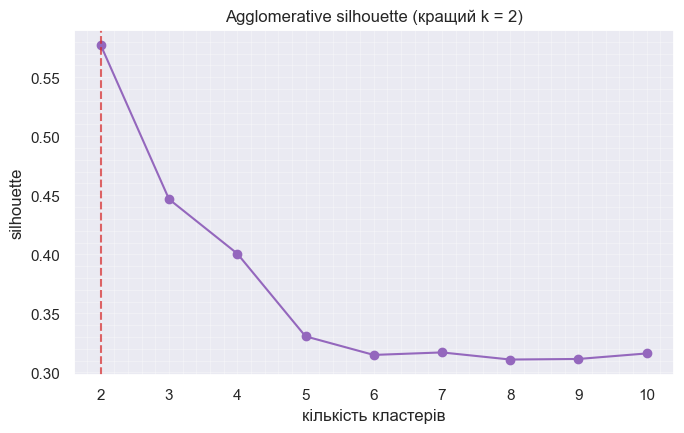

In [18]:
# Silhouette по кількості кластерів. Картина схожа на k-Means: кращий поділ на 2.
best_k_ag = max(sil_agglo, key=sil_agglo.get)
plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), ag_sil, marker="o", color="tab:purple")
plt.axvline(best_k_ag, color="tab:red", ls="--", alpha=0.7)
plt.title(f"Agglomerative silhouette (кращий k = {best_k_ag})")
plt.xlabel("кількість кластерів")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

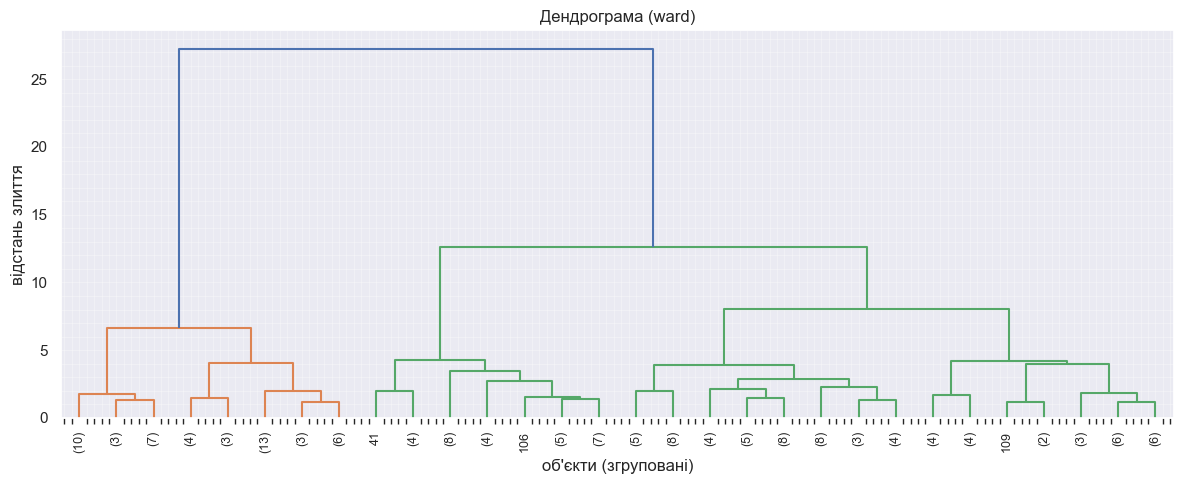

In [19]:
# Дендрограма показує, як точки послідовно зливаються в кластери. Видно дві
# великі гілки - setosa окремо і versicolor+virginica разом. Якщо різати
# нижче, велика гілка ділиться ще на дві (тобто на 3 кластери).
plt.figure(figsize=(12, 5))
Z = linkage(X, method="ward")
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.title("Дендрограма (ward)")
plt.xlabel("об'єкти (згруповані)")
plt.ylabel("відстань злиття")
plt.tight_layout()
plt.show()

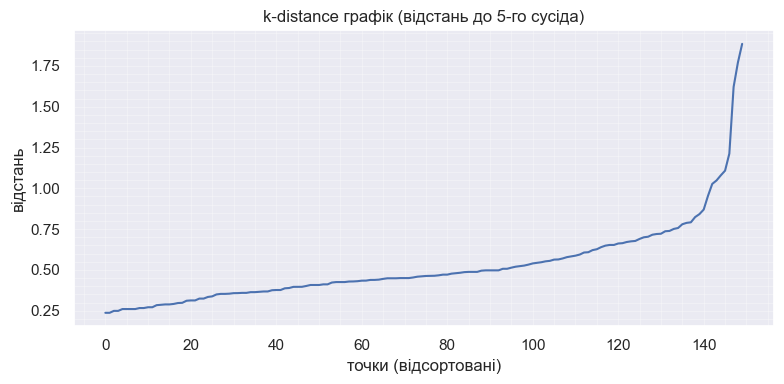

In [20]:
# Крок 7. DBSCAN: кластеризація за щільністю
# Тут кількість кластерів наперед не задаємо - її визначають два параметри:
# eps (радіус сусідства) і min_samples (скільки точок треба поруч, щоб точка
# рахувалась серцевиною). eps підбираємо за k-distance графіком: рахуємо
# відстань кожної точки до 5-го сусіда, сортуємо. Місце зламу - орієнтир для eps.
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
dist, _ = nn.kneighbors(X)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.title(f"k-distance графік (відстань до {min_samples}-го сусіда)")
plt.xlabel("точки (відсортовані)")
plt.ylabel("відстань")
plt.tight_layout()
plt.show()

In [21]:
# Перебираємо eps і дивимось, скільки виходить кластерів, скільки викидів (-1)
# і який silhouette (рахуємо лише по точках, що потрапили в кластери).
def dbscan_stats(eps, min_samples):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    n_noise = int((~mask).sum())
    sil = np.nan
    if n_clusters >= 2:
        sil = silhouette_score(X[mask], labels[mask])
    return n_clusters, n_noise, sil

rows = []
for eps in np.round(np.arange(0.4, 1.5, 0.1), 2):
    n_clusters, n_noise, sil = dbscan_stats(eps, min_samples)
    rows.append((eps, n_clusters, n_noise, round(sil, 3) if sil == sil else np.nan))
pd.DataFrame(rows, columns=["eps", "n_clusters", "n_noise", "silhouette"])

,eps,n_clusters,n_noise,silhouette
0,0.4,6,66,0.486
1,0.5,2,34,0.656
2,0.6,2,26,0.642
3,0.7,2,6,0.602
4,0.8,2,4,0.598
5,0.9,2,4,0.598
6,1.0,2,3,0.595
7,1.1,2,2,0.591
8,1.2,2,1,0.587
9,1.3,2,1,0.587


In [22]:
# Зі зламу на графіку і таблиці беремо eps близько 0.8: два щільних кластери
# з невеликою кількістю викидів. Це знову setosa окремо і versicolor+virginica
# разом - за щільністю ці два види зливаються в один суцільний згусток.
db = DBSCAN(eps=0.8, min_samples=min_samples)
db_labels = db.fit_predict(X)
mask = db_labels != -1
n_clusters_db = len(set(db_labels[mask]))
n_noise_db = int((~mask).sum())
sil_db = silhouette_score(X[mask], db_labels[mask])

print("кластерів:", n_clusters_db)
print("викидів:", n_noise_db)
print("silhouette:", round(sil_db, 3))
pd.Series(db_labels).value_counts().sort_index()

кластерів: 2
викидів: 4
silhouette: 0.598


-1     4
 0    49
 1    97
Name: count, dtype: int64

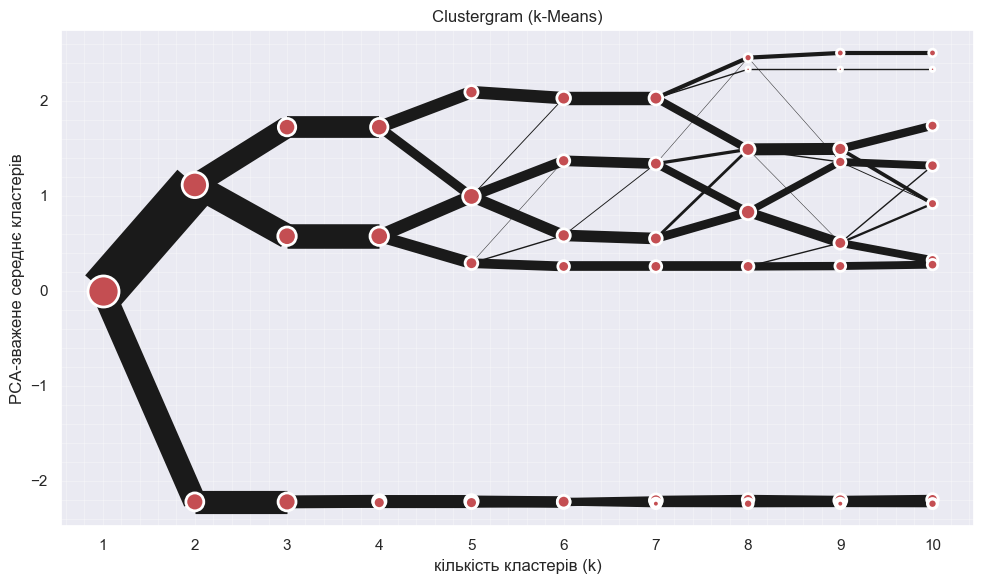

In [23]:
# Крок 8. Clustergram (для k-Means)
# Clustergram показує, як об'єкти переходять між кластерами, коли збільшуємо їх
# кількість від 1 до 10. Товщина ліній - скільки точок іде цим шляхом. Працює
# лише для k-Means.
# Читаємо так: перший поділ (1 -> 2) чистий - знизу товстою гілкою відходить
# setosa. Поділ 2 -> 3 ще акуратний. А з 4 кластерів з'являються тонкі
# перехресні лінії - точки перебігають між кластерами, тобто дрібніші кластери
# нестабільні. Це підказує, що осмислений поділ - десь на 2-3 кластери.
cgram = Clustergram(range(1, 11), n_init=10, random_state=42, verbose=False)
cgram.fit(X)

ax = cgram.plot(figsize=(10, 6))
ax.set_title("Clustergram (k-Means)")
ax.set_xlabel("кількість кластерів (k)")
ax.set_ylabel("PCA-зважене середнє кластерів")
plt.tight_layout()
plt.show()

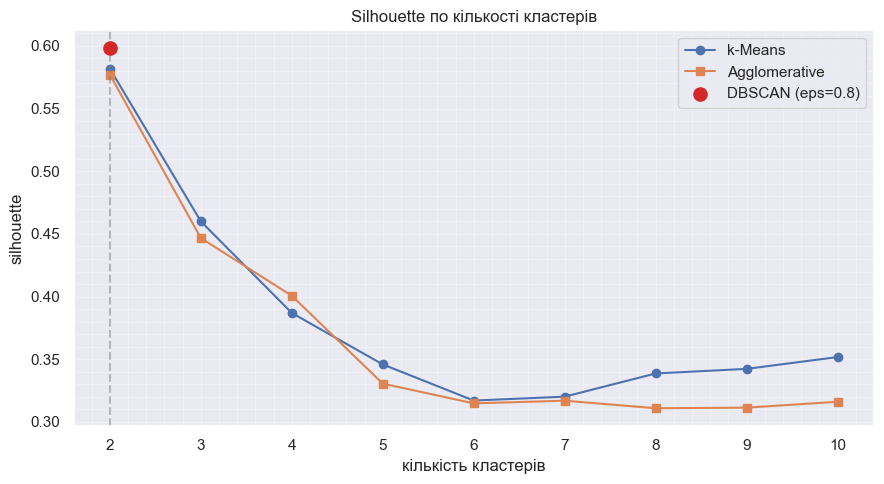

In [24]:
# Крок 9. Зведений графік скорів і вибір кількості кластерів
# Silhouette по кількості кластерів для k-Means і Agglomerative. DBSCAN окремою
# крапкою - він кількість кластерів не приймає на вхід, сам знайшов 2. Значення
# читаємо в межах одного алгоритму по різних k (так шукаємо його оптимум), а не
# порівнюємо алгоритми між собою за величиною silhouette.
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), list(sil_kmeans.values()), marker="o", label="k-Means")
plt.plot(list(k_range), list(sil_agglo.values()), marker="s", label="Agglomerative")
plt.scatter([n_clusters_db], [sil_db], color="tab:red", s=90, zorder=5,
            label="DBSCAN (eps=0.8)")
plt.axvline(2, color="gray", ls="--", alpha=0.5)
plt.title("Silhouette по кількості кластерів")
plt.xlabel("кількість кластерів")
plt.ylabel("silhouette")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Усі три алгоритми дають найвищий silhouette на 2 кластери (setosa проти
# решти). Тобто за графіком скорів оптимальна кількість кластерів = 2.
optimal_k = 2
optimal_k

2

In [26]:
# Довідково: у Iris відомо 3 справжніх види. Глянемо збоку, наскільки поділ
# k-Means на 2 і на 3 кластери збігається зі справжніми видами (ARI: 1 -
# ідеальний збіг). Це не метрика вибору кластерів, а лише перевірка очима.
for k in (2, 3):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    print(f"k={k}: ARI зі справжніми видами = {adjusted_rand_score(df['species'], labels):.3f}")

k=2: ARI зі справжніми видами = 0.568
k=3: ARI зі справжніми видами = 0.620


In [27]:
# Розкладка k-Means (3 кластери) по справжніх видах: setosa виділяється в
# окремий кластер повністю, а versicolor і virginica трохи перемішані між
# двома кластерами. Саме через це перекриття silhouette і віддає перевагу
# 2 кластерам, хоча видів насправді три.
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
pd.crosstab(df["species"], km3, rownames=["вид"], colnames=["кластер"])

кластер,0,1,2
вид,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


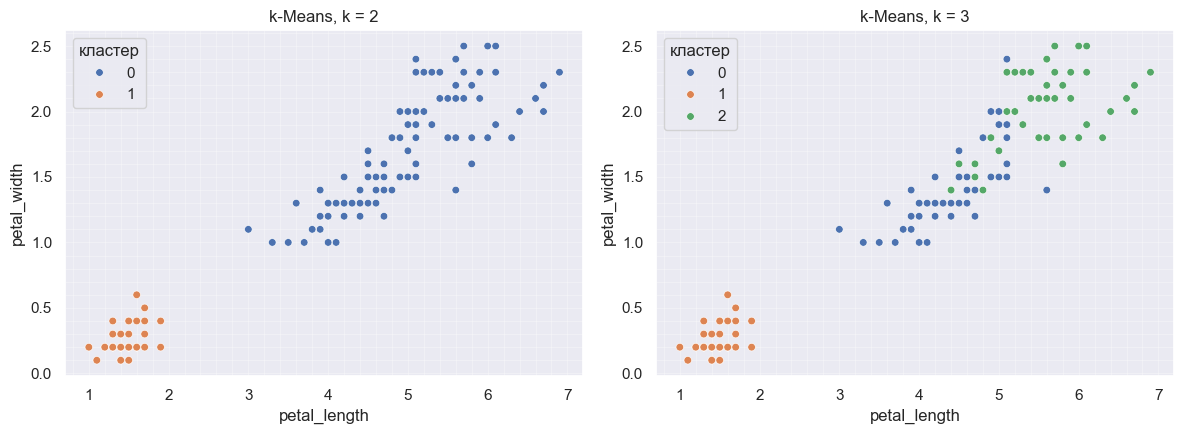

In [28]:
# Наочно порівняємо поділ на 2 і на 3 кластери k-Means у координатах пелюсток -
# саме вони найкраще розводять групи. Зліва setosa чисто відділяється від решти,
# справа видно спробу розділити ще й versicolor з virginica (межа між ними
# розмита, точки на стику лягають то в один, то в інший кластер).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, k in zip(axes, (2, 3)):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    sns.scatterplot(x=df["petal_length"], y=df["petal_width"], hue=labels,
                    palette="deep", s=30, ax=ax)
    ax.set_title(f"k-Means, k = {k}")
    ax.legend(title="кластер")
plt.tight_layout()
plt.show()

In [29]:
# Висновки
# - Три алгоритми сходяться: найкращий за silhouette поділ - на 2 кластери.
#   setosa чітко відділяється, а versicolor і virginica зливаються в одну
#   щільну групу без розриву між ними, тому за відстанню їх важко розвести.
# - Метод ліктя, дендрограма і clustergram підтверджують ту саму картину:
#   стабільний поділ - на 2-3 кластери, далі кластери починають розсипатись.
# - DBSCAN додатково показав, що versicolor+virginica - один суцільний згусток
#   за щільністю (знайшов 2 кластери і кілька викидів).
# - Формально за графіком скорів оптимальна кількість кластерів = 2. Але зі
#   справжніми видами помітно краще збігається поділ на 3. Це той випадок, коли
#   не варто спиратись лише на одну метрику: якщо задача - відділити всі три
#   види, беремо 3 кластери, хоча silhouette тягне на 2.